In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
Data = pd.read_csv("bengaluru_house_prices.csv")

Data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [5]:
summary = Data.describe()
print(summary)

               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000     72.000000
75%        3.000000      2.000000    120.000000
max       40.000000      3.000000   3600.000000


In [14]:
print("Shape:", Data.shape)

Shape: (13320, 9)


<Axes: >

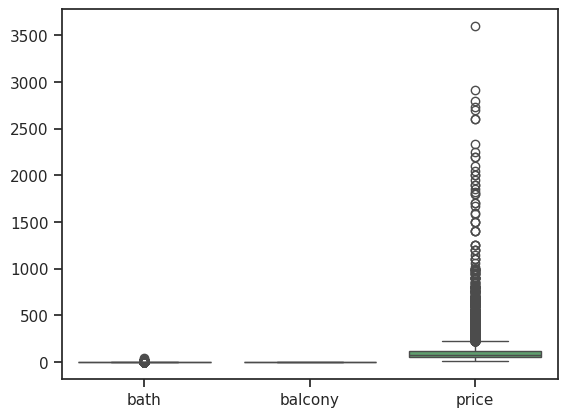

In [6]:
import seaborn as sns
sns.set(style="ticks")
sns.boxplot(data=Data)

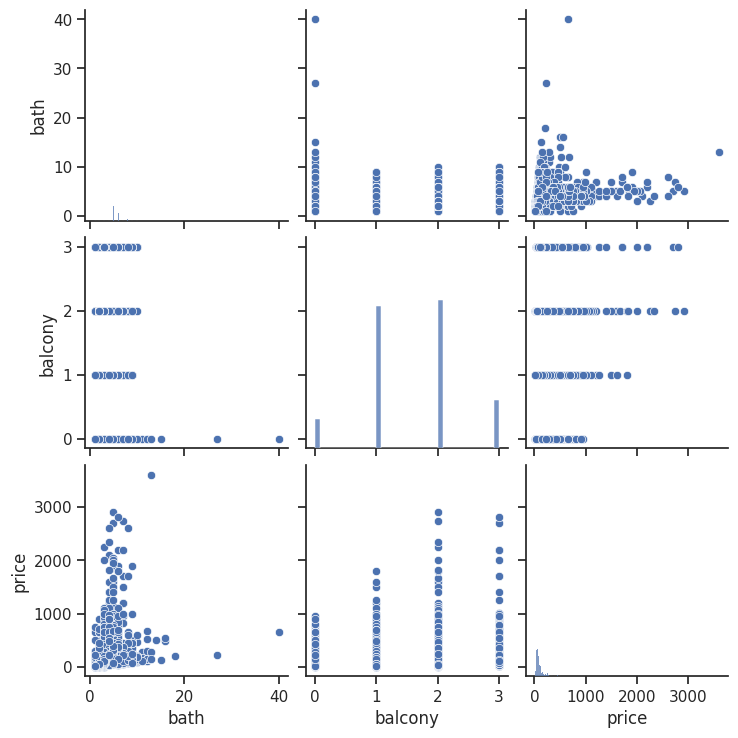

In [7]:
sns.pairplot(data=Data)

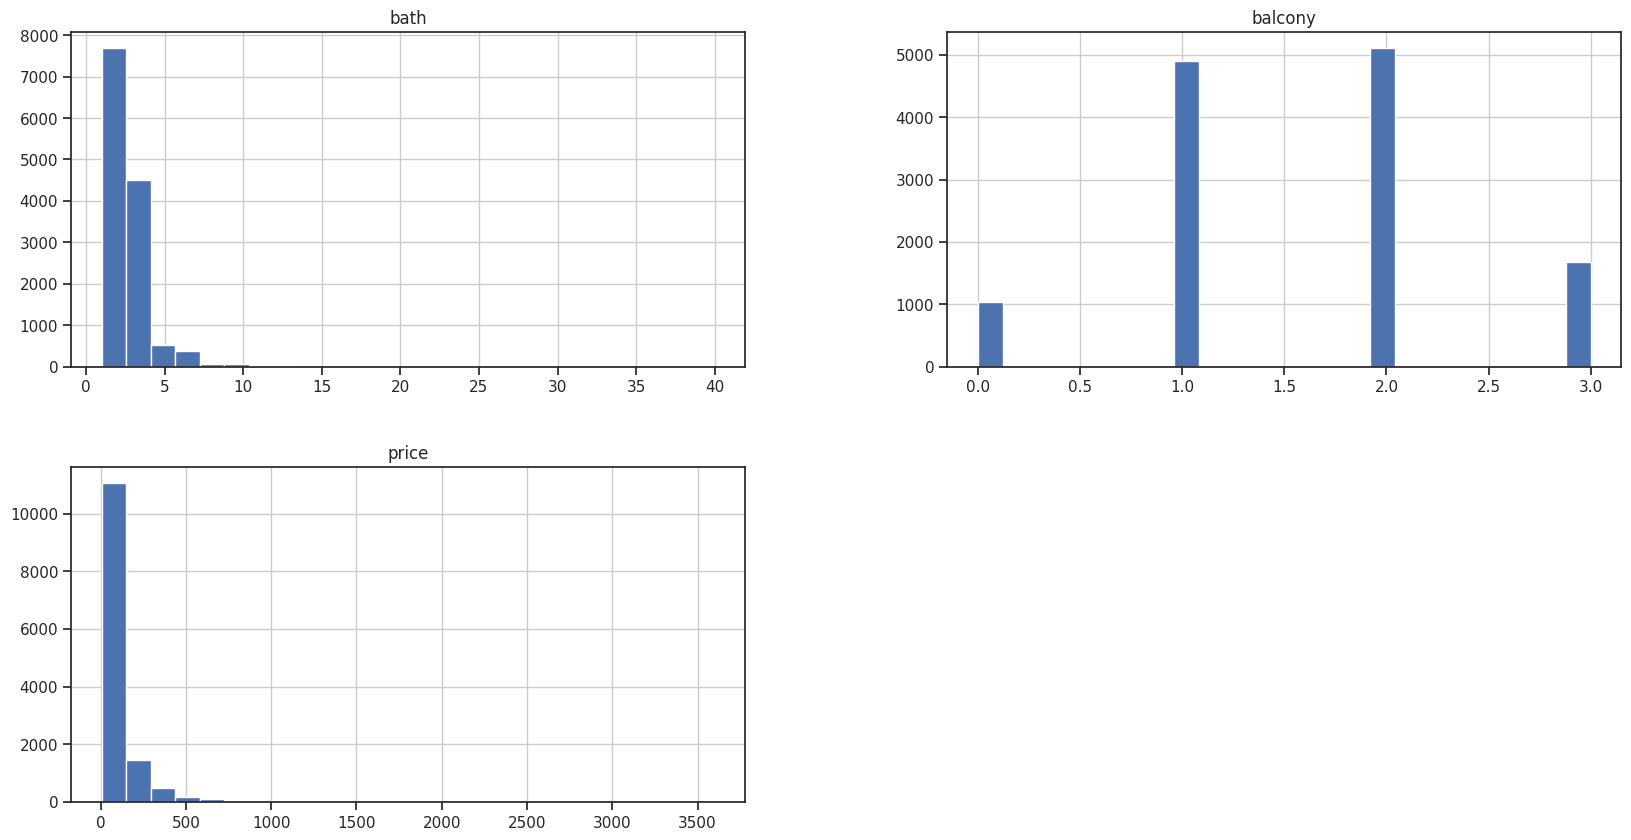

In [8]:
Data.hist(bins=25,figsize=(20,10));

In [12]:
Data.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [11]:
print(Data.dtypes)

area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object


In [15]:
Data.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [17]:
Data["balcony"] = Data["balcony"].fillna(Data["balcony"].median())

In [18]:
Data["bath"] = Data["bath"].fillna(Data["bath"].mode()[0])

In [19]:
Data["size"] = Data["size"].fillna(Data["size"].mode()[0])

In [21]:
Data["location"] = Data["location"].fillna(Data["location"].mode()[0])

In [22]:
Data = Data.drop(columns=["society"])

In [23]:
def convert_sqft(x):
    x = str(x).strip()

    if '-' in x:
        a, b = x.split('-')
        return (float(a) + float(b)) / 2

    try:
        return float(x)
    except:
        return np.nan

In [24]:
Data['total_sqft'] = Data['total_sqft'].apply(convert_sqft)

In [25]:
Data['bhk'] = Data['size'].str.extract(r'(\d+)').astype(float)

In [26]:
Data['ready_to_move'] = (
    Data['availability']
    .str.lower()
    .eq('ready to move')
    .astype(int)
)

In [27]:
availability_date = pd.to_datetime(
    Data['availability'].where(Data['ready_to_move'] == 0),
    format='%y-%b',
    errors='coerce'
)

Data['availability_year'] = availability_date.dt.year
Data['availability_month'] = availability_date.dt.month

In [28]:
Data = Data.dropna(
    subset=['location', 'total_sqft', 'bhk']
)

In [30]:
Data['sqft_per_bhk'] = Data['total_sqft'] / Data['bhk']

Data = Data[Data['sqft_per_bhk'] >= 300]

Data = Data[Data['total_sqft'] <= 30000]

Data = Data[
    (Data['bath'].isna()) |
    (Data['bath'] <= Data['bhk'] + 2)
]

Data = Data.drop(columns=['sqft_per_bhk'])

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_cols = ['bath', 'balcony']

Data[numeric_cols] = scaler.fit_transform(Data[numeric_cols])

print(Data.head())

              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   total_sqft      bath   balcony   price  bhk  ready_to_move  \
0      1056.0  0.066667  0.333333   39.07  2.0              0   
1      2600.0  0.266667  1.000000  120.00  4.0              1   
2      1440.0  0.066667  1.000000   62.00  3.0              1   
3      1521.0  0.133333  0.333333   95.00  3.0              1   
4      1200.0  0.066667  0.333333   51.00  2.0              1   

   availability_year  availability_month  
0             2019.0                12.0  
1                NaN                 NaN  
2    

In [34]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_cols = Data.select_dtypes(include=['int64', 'float64']).columns

Data[numeric_cols] = scaler.fit_transform(Data[numeric_cols])

print(Data.head())

              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   total_sqft      bath   balcony     price       bhk  ready_to_move  \
0    0.025455  0.066667  0.333333  0.010549  0.066667            0.0   
1    0.077441  0.266667  1.000000  0.038422  0.200000            1.0   
2    0.038384  0.066667  1.000000  0.018446  0.133333            1.0   
3    0.041111  0.133333  0.333333  0.029812  0.133333            1.0   
4    0.030303  0.066667  0.333333  0.014658  0.066667            1.0   

   availability_year  availability_month  
0              0.625                 1.0  
1     

In [37]:
features = [
    'area_type',
    'location',
    'total_sqft',
    'bhk',
    'bath',
    'balcony',
    'ready_to_move',
    'availability_year',
    'availability_month'
]

X = Data[features]
y = Data['price']

In [39]:
y = np.log1p(y)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [41]:
categorical_features = [
    'area_type',
    'location'
]

numerical_features = [
    'total_sqft',
    'bhk',
    'bath',
    'balcony',
    'ready_to_move',
    'availability_year',
    'availability_month'
]

In [42]:
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [43]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

In [44]:
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [45]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [46]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(10012, 1125)
(2504, 1125)


In [47]:
model = Sequential([
    Dense(128, activation='relu',
          input_shape=(X_train_processed.shape[1],)),

    Dropout(0.10),

    Dense(64, activation='relu'),

    Dropout(0.10),

    Dense(32, activation='relu'),

    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [49]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       144,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,497 (603.50 KB)

 Trainable params: 154,497 (603.50 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [51]:
history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1)

Epoch 1/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0012 - mae: 0.0184 - val_loss: 7.4093e-04 - val_mae: 0.0136
Epoch 2/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6523e-04 - mae: 0.0124 - val_loss: 7.0470e-04 - val_mae: 0.0115
Epoch 3/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.7780e-04 - mae: 0.0112 - val_loss: 5.8881e-04 - val_mae: 0.0111
Epoch 4/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.5883e-04 - mae: 0.0104 - val_loss: 4.6343e-04 - val_mae: 0.0106
Epoch 5/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.5024e-04 - mae: 0.0093 - val_loss: 4.5704e-04 - val_mae: 0.0097
Epoch 6/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.6697e-04 - mae: 0.0090 - val_loss: 4.7095e-04 - val_mae: 0.0103
Epoch 7/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.9664e-04 - mae: 0.0088 - val_loss: 4.6883e-04 - val_mae: 0.0095
Epoch 8/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2.6028e-04 - mae: 0.0083 - val_loss: 5.3320e-04 - val_

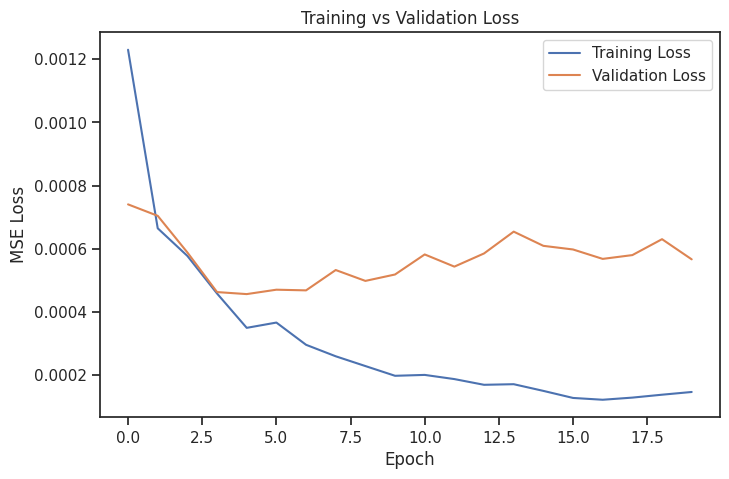

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [53]:
y_pred_log = model.predict(X_test_processed)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [54]:
y_pred = np.expm1(y_pred_log.flatten())
y_test_original = np.expm1(y_test)

In [55]:
mae = mean_absolute_error(y_test_original,y_pred)
print("MAE:", mae)

MAE: 0.010596810073619728


In [56]:
mse = mean_squared_error(y_test_original, y_pred)
print("MSE:", mse)

MSE: 0.0008862603152142918


In [57]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 0.029770124541464247


In [58]:
r2 = r2_score(y_test_original,y_pred)
print("R²:", r2)

R²: 0.6352191337558655


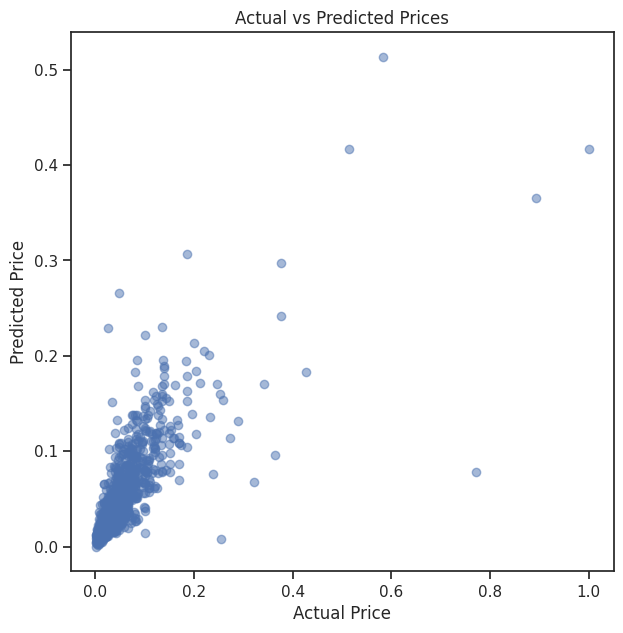

In [59]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test_original,
    y_pred,
    alpha=0.5)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()

In [60]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dropout(0.10),
    Dense(64, activation='relu'),
    Dropout(0.10),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [61]:
history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping])

Epoch 1/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 9.8346e-04 - mae: 0.0181 - val_loss: 8.2356e-04 - val_mae: 0.0126
Epoch 2/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.1750e-04 - mae: 0.0131 - val_loss: 9.0703e-04 - val_mae: 0.0182
Epoch 3/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.5816e-04 - mae: 0.0116 - val_loss: 7.9572e-04 - val_mae: 0.0113
Epoch 4/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.8226e-04 - mae: 0.0112 - val_loss: 7.6529e-04 - val_mae: 0.0111
Epoch 5/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.4626e-04 - mae: 0.0101 - val_loss: 5.3374e-04 - val_mae: 0.0108
Epoch 6/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3.0607e-04 - mae: 0.0088 - val_loss: 4.4403e-04 - val_mae: 0.0097
Epoch 7/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.9986e-04 - mae: 0.0084 - val_loss: 7.6158e-04 - val_mae: 0.0115
Epoch 8/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.3650e-04 - mae: 0.0078 - val_loss: 5.3029e-04 - 